# COSC-640: Lab 5

**Ben Miller**

[PLACEHOLDER_FOR_NOTEBOOK_LINK]


## Getting Started

Follow the instructions below to copy this notebook and to perform some initial setup.

1. Copy this notebook by selecting `File > Save a copy in Drive`.
2. A new window should open for the copied notebook. Move the new notebook to your course folder in Google Drive by selecting `File > Move` and then selecting the desired folder.
3. Update the name of the notebook by removing "Copy of" and replacing "Username" with your actual username.
4. Update the first cell in the notebook by specifying your course number (440 or 640) and by replacing "**Student Name**" with your actual name.
5. Do not edit the line that says `PLACEHOLDER_FOR_NOTEBOOK_LINK`. This will be used by the [Notebook Renderer](https://colab.research.google.com/drive/1CJTipys46ldZxJFwnt7XbdjQUfkmoXeU?usp=sharing) tool to insert a link to your Colab notebook.
6. Enable link sharing for your notebook.

## Preparing the Colab Environment

Run the cell below to download and extract the datasets required for this lab. All of the required datasets will then be stored on the Colab VM in a folder named `data/`.

In [1]:
%%capture
!wget -nc https://github.com/drbeane/datasets/raw/main/COSC_640_data.zip
!unzip -n COSC_640_data.zip -d data/

Run the cell below to import the necessary tools for this assignment. **No other import statements are required for this Lab, and no other import statements should be included in this assignment.**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

np.set_printoptions(linewidth=150)

# Part 1: Mobile Device Price Data

In Part 1, you will be working with a synthetic dataset containing information about several mobile devices. Your goal is to build a model to predict which of four price groups a mobile device falls into based on its characteristics. You can find more information about the dataset, including a description of the features here: [Kaggle: Mobile Price Classification](https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification)

## 1.A - Load the Data

Load the data from the file `data/mobile.csv` into a DataFrame. Use the `sample()` method to shuffle the data, setting `random_state=1`. Display the head of the DataFrame.

In [3]:
mobile_data = pd.read_csv('data/mobile.csv')
mobile_data = mobile_data.sample(frac=1, random_state=1)

## 1.B - Label Distribution
Use the `value_counts()` method to display the distribution of the label values as proportions. Note that labels are stored in the `price_group` column.

In [4]:
mobile_data.price_group.value_counts(normalize=True)

,proportion
price_group,
Group 0,0.25
Group 1,0.25
Group 2,0.25
Group 3,0.25


## 1.C - Feature and Label Arrays

Create a feature array containing all columns of your DataFrame except for `price_group`. Then create a label array. Display the shape of both arrays.

In [5]:
x_train = mobile_data.loc[:, mobile_data.columns != 'price_group'].values
y_train = mobile_data.loc[:, 'price_group'].values

print(x_train.shape)
print(y_train.shape)

(2000, 20)
(2000,)


## 1.D - Feature Scaling

Create an instance of StandardScaler and use it to create a scaled feature array.

**Use scaled features when training, evaluating, or applying models in Part 1.**

In [6]:
scaler = StandardScaler()
scaled_x = scaler.fit_transform(x_train)

## 1.E - Cross Validation for Logistic Regression

Create an instance of `LogisticRegression`. Use `cross_value_score()` to estimate the model's out-of-sample performance on the dataset. Use 10-fold CV with "accuracy" as the metric and set `n_jobs=-1`. Print the scores for each fold, as well as mean score. Round all scores to 3 decimal places.

In [7]:
lr_model = LogisticRegression()
scores = cross_val_score(lr_model, scaled_x, y_train, cv=10, scoring='accuracy', n_jobs=-1)
cv_score = np.mean(scores)
print(scores.round(3))
print(round(cv_score, 3))

[0.975 0.96  0.96  0.97  0.96  0.975 0.97  0.97  0.96  0.95 ]
0.965


## 1.F - Cross Validation for KNN

Create an instance of `KNeighborsClassifier`, selecting a value of your choice for `n_neighbors`. Use `cross_value_score()` to estimate the model's out-of-sample performance on the dataset. Use 10-fold CV with accuracy as the metric and set `n_jobs=-1`. Print the scores for each fold, as well as mean score. Round all scores to 3 decimal places.

Experiment with the value of `n_neighbors` until you find a model with a CV score of **at least 0.69**.

In [8]:
knn_model = KNeighborsClassifier(n_neighbors=225)
scores = cross_val_score(knn_model, scaled_x, y_train, cv=10, scoring='accuracy', n_jobs=-1)
cv_score = np.mean(scores)
print(scores.round(3))
print(round(cv_score, 3))

[0.72  0.715 0.705 0.72  0.7   0.67  0.645 0.735 0.675 0.65 ]
0.694


## 1.G - Classification Report

Identify which of the two models gave you the best results. Then use that model with `cross_val_predict()` with `cv=10` to generate out-of-sample predictions for the dataset. Use these predictions with `classification_report()` to generate a classification report.


In [9]:
predictions = cross_val_predict(lr_model, scaled_x, y_train, cv=10)
classification_report(y_train, predictions)

'              precision    recall  f1-score   support\n\n     Group 0       0.98      0.98      0.98       500\n     Group 1       0.96      0.94      0.95       500\n     Group 2       0.95      0.95      0.95       500\n     Group 3       0.97      0.98      0.98       500\n\n    accuracy                           0.96      2000\n   macro avg       0.96      0.96      0.96      2000\nweighted avg       0.96      0.96      0.96      2000\n'

## 1.H - Confusion Matrix

Use your out-of-sample predictions with `confusion_matrix()` to generate a confusion matrix. Display the confusion matrix as a DataFrame, with the rows and columns labeled according to the actual class names.

In [10]:
cm = confusion_matrix(y_train, predictions)
labels = np.unique(y_train)
df_cm = pd.DataFrame(cm, index=labels, columns=labels)
df_cm

,Group 0,Group 1,Group 2,Group 3
Group 0,490,10,0,0
Group 1,12,472,16,0
Group 2,0,11,476,13
Group 3,0,0,8,492


## 1.I - Applying the Model

Lists containing feature values for two new observations have been provided for you in the cell below. Scale these using the scaler you created earlier. Then fit your best-performing model to the training data and use the `predict_proba()` method to generate probability predictions for the new observations. Print the resulting probability array.

In [11]:
x1 = [1537, 0, 1, 0, 6, 1, 19, 0, 86, 8, 2, 882, 1704, 794, 13, 1, 4, 1, 0, 1]
x2 = [1864, 0, 1, 1, 5, 0, 47, 0, 159, 6, 8, 119, 1788, 2423, 12, 1, 3, 1, 1, 1]

X_new = [x1, x2]

In [12]:
X_new_scaled = scaler.transform(X_new)
lr_model.fit(scaled_x, y_train)
probabilities = lr_model.predict_proba(X_new_scaled)
print(probabilities)

[[3.75393821e-01 6.22116922e-01 2.48924851e-03 8.25684804e-09]
 [5.68902536e-08 5.56033124e-03 8.45883773e-01 1.48555839e-01]]


# Part 2: MNIST Dataset

In Part 2, you will be working with image data consisting of many 28x28 images of hand-written digits. Your goal is to create a model that can predict the digit shown in the image based on its pixel values. You can find more information about the dataset, including a description of the features here: [Kaggle: Digit Recognizer](https://www.kaggle.com/competitions/digit-recognizer/data)

## 2.A - Load the Data

Load the data from the file `data/MNIST.csv` into a DataFrame. Use the `sample()` method to shuffle the data, setting `random_state=1`. Display the head of the DataFrame.

In [13]:
mnist_data = pd.read_csv('data/MNIST.csv')
mnist_data = mnist_data.sample(frac=1, random_state=1)
mnist_data.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,label
6670,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6
49567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
50796,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
22310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
54037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7


## 2.B - Label Distribution
Use the `value_counts()` method to display the distribution of the label values as proportions. Note that labels are stored in the `label` column.

In [14]:
mnist_data.label.value_counts(normalize=True)

,proportion
label,
1,0.112529
7,0.104186
3,0.102014
2,0.099857
9,0.099400
0,0.098614
6,0.098229
8,0.097500
4,0.097486


## 2.C - Feature and Label Arrays

Create a feature array containing all columns of your DataFrame except for `label`. Then create a label array. Display the shape of both arrays.

In [15]:
x_train = mnist_data.loc[:, mnist_data.columns != 'label'].values
y_train = mnist_data.loc[:, 'label'].values

print(x_train.shape)
print(y_train.shape)

(70000, 784)
(70000,)


## 2.D - Feature Scaling

Each feature value in this dataset is a pixel value ranging from 0 to 255. Scale all of the feature values to be between 0 and 1 by dividing all values in the feature array by 255. Store the results in a new scaled feature array.

Note that we are not using a scaler in this problem because all of the feature values are on the same scale to begin with. We just need to compress that scale down to `[0, 1]`.

**Use scaled features when training, evaluating, or applying models in Part 2.**

In [16]:
scaled_feature = x_train / 255
print(scaled_feature)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


## 2.E - Displaying a Digit

Select the first row of your feature array and reshape it to `28x28`, storing the result in a new variable. Display the digit using the `plt.imshow()` function of Matplotlib. Set `cmap='Greys'` when calling `imshow()`. Turn off the axes and then use `plt.show()` to display the digit.

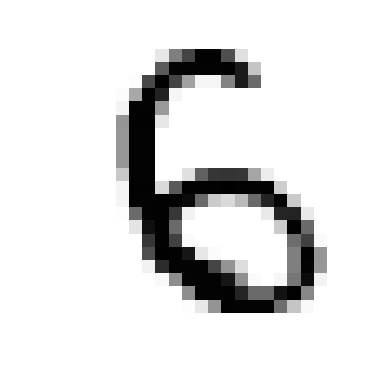

In [17]:
digit = scaled_feature[0,:].reshape(28, 28)
plt.imshow(digit, cmap='Greys')
plt.axis('off')
plt.show()

## 2.F - Cross Validation for Logistic Regression

Create an instance of `LogisticRegression`, setting `solver='saga'` and `tol=0.1`. Use `cross_value_score()` to estimate the model's out-of-sample performance on the dataset. Use 10-fold CV with accuracy as the metric and set `n_jobs=-1`. Print the scores for each fold, as well as mean score. Round all scores to 3 decimal places.

Note that this could take a few minutes to run.

In [18]:
lr_model = LogisticRegression(solver='saga', tol=0.1)
scores = cross_val_score(lr_model, scaled_feature, y_train, cv=10, scoring='accuracy', n_jobs=-1)
cv_score = np.mean(scores)
print(scores.round(3))
print(round(cv_score, 3))

[0.917 0.924 0.927 0.92  0.924 0.923 0.92  0.923 0.924 0.923]
0.923


## 2.G - Cross Validation for KNN

Create an instance of `KNeighborsClassifier`, setting `n_neighbors=5`. Use `cross_value_score()` to estimate the model's out-of-sample performance on the dataset. Use 10-fold CV with accuracy as the metric and set `n_jobs=-1`. Print the scores for each fold, as well as mean score. Round all scores to 3 decimal places.

Experiment with the value of `n_neighbors` until you find a model with a CV score of **at least 0.97**.

Note that this could take a few minutes to run.

In [19]:
knn_model = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(knn_model, scaled_feature, y_train, cv=10, scoring='accuracy', n_jobs=-1)
cv_score = np.mean(scores)
print(scores.round(3))
print(round(cv_score, 3))

[0.973 0.972 0.971 0.971 0.972 0.971 0.972 0.975 0.971 0.975]
0.972


## 2.H - Classification Report

Identify which of the two models gave you the best results. Then use that model with `cross_val_predict()` with `cv=10` to generate out-of-sample predictions for the dataset. Use these predictions with `classification_report()` to generate a classification report.

Note that this could take a few minutes to run.

In [20]:
cv_pred = cross_val_predict(knn_model, scaled_feature, y_train, cv=10, n_jobs=-1)
classification_report(y_train, cv_pred)

'              precision    recall  f1-score   support\n\n           0       0.98      0.99      0.99      6903\n           1       0.96      1.00      0.98      7877\n           2       0.98      0.96      0.97      6990\n           3       0.97      0.97      0.97      7141\n           4       0.98      0.97      0.97      6824\n           5       0.97      0.97      0.97      6313\n           6       0.98      0.99      0.98      6876\n           7       0.96      0.97      0.97      7293\n           8       0.99      0.93      0.96      6825\n           9       0.96      0.96      0.96      6958\n\n    accuracy                           0.97     70000\n   macro avg       0.97      0.97      0.97     70000\nweighted avg       0.97      0.97      0.97     70000\n'

## 2.I - Confusion Matrix

Use your out-of-sample predictions with `confusion_matrix()` to generate a confusion matrix. Display the confusion matrix as a DataFrame, with the rows and columns labeled according to the actual class names.

In [21]:
cm = confusion_matrix(y_train, cv_pred)
labels = np.unique(y_train)
pd.DataFrame(cm, index=labels, columns=labels)

,0,1,2,3,4,5,6,7,8,9
0,6859,5,4,0,1,7,18,3,2,4
1,1,7840,11,1,3,1,3,14,1,2
2,43,55,6743,15,9,3,10,93,14,5
3,5,16,39,6912,1,63,3,45,33,24
4,4,50,2,1,6611,0,16,11,3,126
5,20,9,3,74,6,6096,60,6,7,32
6,28,15,1,0,8,21,6802,0,1,0
7,2,80,16,2,15,2,0,7109,3,64
8,25,78,20,81,34,107,29,17,6380,54
9,17,16,9,42,59,12,4,74,14,6711


## 2.J - Displaying New Digits

The csv file `data/new_digits.csv` contains pixel values for 3 new digits. Load this data into a DataFrame. Then display these digits in a 1x3 grid of subplots using `plt.imshow()` with `cmap='Greys'`. As before, turn off the axes for each subplot.

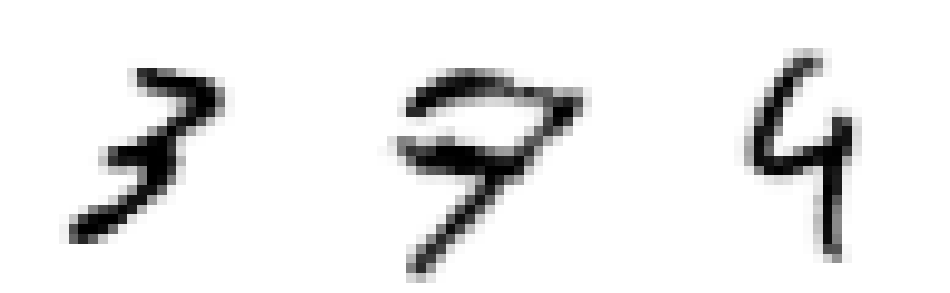

In [22]:
digits_data = pd.read_csv('data/new_digits.csv')

fig = plt.figure(figsize=(12, 4))

sub1 = plt.subplot(1,3,1)
sub1.imshow(digits_data.iloc[0].values.reshape(28,28), cmap='Greys')
sub1.axis('off')

sub2 = plt.subplot(1,3,2)
sub2.imshow(digits_data.iloc[1].values.reshape(28,28), cmap='Greys')
sub2.axis('off')

sub3 = plt.subplot(1,3,3)
sub3.imshow(digits_data.iloc[2].values.reshape(28,28), cmap='Greys')
sub3.axis('off')

plt.show()


## 2.K - Applying the Model

Create a new array containing scaled values for the new digits. Fit your best-performing model to the training data. Then use the `predict()` and `predict_proba()` method to generate class predictions and class probability estimates for the new observations. Print the resulting class predictions and probability estimates.

In [23]:
new_digits_scaled = digits_data.values / 255

knn_model.fit(scaled_feature, y_train)

pred = knn_model.predict(new_digits_scaled)
print(pred)

prob = knn_model.predict_proba(new_digits_scaled)
print(prob)

[3 9 4]
[[0.  0.  0.  0.8 0.  0.  0.  0.2 0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.2 0.  0.8]
 [0.  0.  0.  0.  0.6 0.  0.  0.  0.  0.4]]


# Submission Instructions

1. Perform a Restart and Run All by clicking **Runtime > Restart session and run all**.
2. Copy the link to your notebook by clicking **Share > Copy Link**.
3. Paste the copied link into the `notebook_url` field in the [Notebook Renderer](https://colab.research.google.com/drive/1CJTipys46ldZxJFwnt7XbdjQUfkmoXeU?usp=sharing) tool and then execute the cell to render the notebook.
4. The Notebook Renderer will open up a save file dialog. Save the resulting HTML file yo your local machine.
5. Submit the HTML file to Canvas.
